# Participant 3: standardized comparison of three hierarchical observers

This notebook compares three implementations under one observation model. Every
model receives the same chronological participant-3 trials, coherence, true
direction feedback, session boundaries, response grid, motor-noise process,
lapse process, optimizer, and score calculation.

The experimenter's `prior_std` label is neither passed to nor retained by any
observer. State resets at session boundaries and carries across blocks within a
session. Parameters are fitted by maximum likelihood; "hierarchical" refers to
the observer's latent prior-confidence structure, not population-level partial
pooling across participants.

Participant 3 was selected from the paper rather than from a fitted result in this codebase. Figure 5F displays `sub03` as a clear subject-level bimodality example, and Figure 5E reports a 670-point AIC advantage for the Switching observer over the Basic Bayesian observer.

## Models and equations

Let (d_t) be the true direction, (m_t) an internal measurement,
(mu_0=225^circ), and (VM(cdot;mu,kappa)) a von Mises distribution.

**Readout-average** forms a contaminated direction prior for each candidate
precision,

\[
\pi_\kappa(\theta)=\alpha VM(\theta;\mu_0,\kappa)+(1-\alpha)U(\theta),
\]

takes a MAP readout conditional on each \(\kappa\), and averages the resulting
response distributions using \(b_t(\kappa)\).

**Reliability-mixture** directly mixes a prior-centered and stimulus-centered
component,

\[
p(q_t)=r_tVM(q_t;\mu_0,\kappa_p)+(1-r_t)VM(q_t;d_t,\kappa_e[c_t]),
\]

where \(r_t\) follows a five-feedback delta-rule update. The standardized
version has one fitted \(\kappa_p\), not four `prior_std`-indexed values.

**Integrated-prior** first marginalizes precision uncertainty,

\[
\pi_t(\theta)=\sum_\kappa H_t(\kappa)VM(\theta;\mu_0,\kappa),
\]

then forms one posterior

\[
p(\theta\mid m_t,H_t)\propto VM(\theta;m_t,\kappa_e[c_t])\pi_t(\theta)
\]

and applies one tie-aware MAP readout.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / "src" / "standardized_hb").exists():
            return candidate
        nested = candidate / "standardized_hierarchical_comparison"
        if (nested / "src" / "standardized_hb").exists():
            return nested
    raise FileNotFoundError("Could not locate standardized_hierarchical_comparison.")


PROJECT_ROOT = find_project_root(Path.cwd())
WORKSPACE_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from standardized_hb import (
    FitConfig,
    GridSpec,
    IntegratedPriorObserver,
    ReadoutAverageObserver,
    ReliabilityMixtureObserver,
    fit_model,
    load_participant,
)
from standardized_hb.plotting import (
    paper_bimodality_figure,
    score_and_response_figure,
    state_figure,
)

print("project:", PROJECT_ROOT)

project: C:\Users\HP\Desktop\baysiean hyperprior\standardized_hierarchical_comparison


## Run configuration

The normal run fits all 9,412 participant-3 trials with two starts per model.
Each start receives 250 objective evaluations by default, which is large enough
for Powell to revisit the parameter vector instead of stopping during its first
few coordinate searches. Override the budget
with `HB_MAX_EVALUATIONS_PER_START`; `HB_SMOKE_TEST=1` retains the full trial
sequence but uses five evaluations for a pipeline check.

The integrated-prior likelihood is substantially more expensive than the other
two. At the observed 5-10 seconds per objective evaluation, the default normal
run can take roughly 45-90 minutes for that model. A run is scientifically
interpretable only when the convergence table below reports success.

In [2]:
SMOKE_TEST = os.environ.get("HB_SMOKE_TEST", "0") == "1"
GRID = GridSpec(
    n_angles=72,
    n_positive_kappa=9,
    kappa_min=0.05,
    kappa_max=50.0,
    prior_mean_degrees=225.0,
)
NORMAL_MAX_EVALUATIONS_PER_START = int(
    os.environ.get("HB_MAX_EVALUATIONS_PER_START", "250")
)
if not SMOKE_TEST and NORMAL_MAX_EVALUATIONS_PER_START < 100:
    raise ValueError("Normal fits require at least 100 evaluations per start.")

FIT_CONFIG = FitConfig(
    n_starts=1 if SMOKE_TEST else 2,
    max_evaluations_per_start=5 if SMOKE_TEST else NORMAL_MAX_EVALUATIONS_PER_START,
    seed=20260721,
)
RUN_LABEL = "smoke_participant_3" if SMOKE_TEST else "participant_3"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / RUN_LABEL
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

run_config = {
    "smoke_test": SMOKE_TEST,
    "participant_id": 3,
    "n_angles": GRID.n_angles,
    "angle_step_degrees": 360.0 / GRID.n_angles,
    "kappa_support": GRID.kappa_values.tolist(),
    "n_starts": FIT_CONFIG.n_starts,
    "max_evaluations_per_start": FIT_CONFIG.max_evaluations_per_start,
    "prior_std_used": False,
    "state_reset": "session boundary",
    "state_carryover": "across blocks within a session",
}
display(pd.DataFrame.from_dict(run_config, orient="index", columns=["value"]))

,value
smoke_test,False
participant_id,3
n_angles,72
angle_step_degrees,5.0
kappa_support,"[0.0, 0.05, 0.11856868528308274, 0.28117066259..."
n_starts,2
max_evaluations_per_start,250
prior_std_used,False
state_reset,session boundary
state_carryover,across blocks within a session


## Load participant 3

The loader intentionally has no `prior_std` field. Missing responses would be
excluded from scoring but their true-direction feedback would still update the
latent state.

In [3]:
DATA_CANDIDATES = [
    WORKSPACE_ROOT / "hierarchical" / "data" / "data01_direction4priors.csv",
    Path.home() / "Downloads" / "data01_direction4priors.csv",
]
DATA_CSV = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_CSV is None:
    raise FileNotFoundError(f"Data not found. Checked: {DATA_CANDIDATES}")

subject, audit = load_participant(DATA_CSV, subject_id=3, grid=GRID)
assert not hasattr(subject, "prior_std")
assert audit["prior_std_used"] is False
display(pd.DataFrame.from_dict(audit, orient="index", columns=["value"]))

,value
csv_path,C:\Users\HP\Desktop\baysiean hyperprior\hierar...
subject_id,3
trials,9412
valid_responses,9412
sessions,9
runs,44
coherences,"[0.06, 0.12, 0.24]"
prior_mean_degrees,225.0
prior_std_used,False


## Construct the three observers and validate their default predictions

In [4]:
observers = {
    "readout_average": ReadoutAverageObserver(subject, GRID, batch_size=128),
    "reliability_mixture": ReliabilityMixtureObserver(subject, GRID, batch_size=128),
    "integrated_prior": IntegratedPriorObserver(subject, GRID, batch_size=128),
}

preflight = []
for name, observer in observers.items():
    started = perf_counter()
    raw = observer.default_raw_parameters()
    prediction = observer.predict(raw)
    row_sums = prediction.response_pmfs.sum(axis=1)
    nll = observer.negative_log_likelihood(raw)
    preflight.append(
        {
            "model": name,
            "parameters": observer.parameter_count,
            "default_nll": nll,
            "maximum_normalization_error": float(np.max(np.abs(row_sums - 1.0))),
            "elapsed_seconds": perf_counter() - started,
        }
    )
preflight_table = pd.DataFrame(preflight)
assert (preflight_table["maximum_normalization_error"] < 1e-10).all()
display(preflight_table)

,model,parameters,default_nll,maximum_normalization_error,elapsed_seconds
0,readout_average,7,27792.632153,4.440892e-16,0.821765
1,reliability_mixture,7,31691.689973,3.330669e-16,0.904139
2,integrated_prior,6,28269.868891,4.440892e-16,12.359177


## Fit all three models

Each optimizer sees the same trials and transformed parameter bounds. AIC and
BIC use the same response binning and lapse likelihood, but they are treated as
valid model-comparison statistics only after all three optimizers converge.

In [5]:
fit_results = {}
for name, observer in observers.items():
    print(f"Fitting {name} ...", flush=True)
    result = fit_model(observer, FIT_CONFIG)
    fit_results[name] = result
    print(
        f"  NLL={result.nll:.2f}, AIC={result.aic:.2f}, "
        f"evaluations={result.evaluations}, elapsed={result.elapsed_seconds:.1f}s",
        flush=True,
    )

Fitting readout_average ...
  NLL=26940.43, AIC=53894.86, evaluations=437, elapsed=100.0s
Fitting reliability_mixture ...
  NLL=27253.13, AIC=54520.26, evaluations=500, elapsed=204.3s
Fitting integrated_prior ...
  NLL=27081.01, AIC=54174.01, evaluations=430, elapsed=2510.0s


## Compare scores and fitted parameters

In [6]:
comparison_valid = all(result.success for result in fit_results.values())
score_table = pd.DataFrame(
    [
        {
            "model": name,
            "n_parameters": observers[name].parameter_count,
            "nll": result.nll,
            "aic": result.aic,
            "bic": result.bic,
            "delta_aic": result.aic - min(item.aic for item in fit_results.values()),
            "evaluations": result.evaluations,
            "elapsed_seconds": result.elapsed_seconds,
            "optimizer_success": result.success,
            "comparison_valid": comparison_valid,
        }
        for name, result in fit_results.items()
    ]
).sort_values("aic").reset_index(drop=True)
display(score_table)

parameter_table = pd.DataFrame(
    {name: result.parameters for name, result in fit_results.items()}
).T
display(parameter_table)

convergence_rows = []
for name, result in fit_results.items():
    observer = observers[name]
    fitted = np.asarray(result.raw_parameters)
    initial = observer.default_raw_parameters()
    bounds = np.asarray(observer.raw_bounds, dtype=float)
    widths = bounds[:, 1] - bounds[:, 0]
    tolerance = 1e-3 * widths
    unchanged = np.abs(fitted - initial) <= tolerance
    at_bound = (
        (fitted - bounds[:, 0] <= tolerance)
        | (bounds[:, 1] - fitted <= tolerance)
    )
    convergence_rows.append(
        {
            "model": name,
            "success": result.success,
            "message": result.message,
            "unchanged_raw_parameters": ", ".join(
                np.asarray(observer.raw_parameter_names)[unchanged]
            ) or "none",
            "bound_hits": ", ".join(
                np.asarray(observer.raw_parameter_names)[at_bound]
            ) or "none",
        }
    )
convergence_table = pd.DataFrame(convergence_rows)
display(convergence_table)

if not comparison_valid:
    print(
        "WARNING: At least one optimizer did not converge. AIC/BIC and fitted "
        "trajectories below are provisional diagnostics, not a valid final model comparison."
    )

,model,n_parameters,nll,aic,bic,delta_aic,evaluations,elapsed_seconds,optimizer_success,comparison_valid
0,readout_average,7,26940.428398,53894.856796,53944.904982,0.000000,437,99.970796,False,False
1,integrated_prior,6,27081.006981,54174.013962,54216.912407,279.157166,430,2510.036151,True,False
2,reliability_mixture,7,27253.129204,54520.258408,54570.306593,625.401612,500,204.280639,False,False


,alpha,motor_kappa,lapse,lambda,sensory_kappa_0.06,sensory_kappa_0.12,sensory_kappa_0.24,prior_kappa,learning_rate,rho
readout_average,0.667024,31.080979,0.012843,0.26146,2.298380,10.385305,79.958355,NaN,NaN,NaN
reliability_mixture,NaN,39.031890,0.010130,NaN,2.784729,14.322469,79.954209,79.927585,0.070699,NaN
integrated_prior,NaN,24.632671,0.019539,NaN,2.518046,10.417953,79.960047,NaN,NaN,0.75466


,model,success,message,unchanged_raw_parameters,bound_hits
0,readout_average,False,Maximum number of function evaluations has bee...,none,log_sensory_kappa_0.24
1,reliability_mixture,False,Maximum number of function evaluations has bee...,none,"log_sensory_kappa_0.24, log_prior_kappa"
2,integrated_prior,True,Optimization terminated successfully.,none,log_sensory_kappa_0.24


## Generate and save fitted trial-level predictions

In [7]:
predictions = {
    name: observers[name].predict(result.raw_parameters)
    for name, result in fit_results.items()
}

payload = {
    "run_config": run_config,
    "data_audit": audit,
    "fits": {name: result.summary_record() for name, result in fit_results.items()},
}
with (OUTPUT_DIR / "fit_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(payload, handle, indent=2, default=lambda value: value.item() if hasattr(value, "item") else str(value))

score_table.to_csv(OUTPUT_DIR / "model_scores.csv", index=False)
parameter_table.to_csv(OUTPUT_DIR / "fitted_parameters.csv", index=True)
for name, result in fit_results.items():
    result.history.to_csv(OUTPUT_DIR / f"{name}_optimization_history.csv", index=False)
    np.savez_compressed(
        OUTPUT_DIR / f"{name}_predictions.npz",
        response_pmfs=predictions[name].response_pmfs,
        state=predictions[name].state,
        raw_parameters=result.raw_parameters,
    )
print("saved:", OUTPUT_DIR)

saved: C:\Users\HP\Desktop\baysiean hyperprior\standardized_hierarchical_comparison\outputs\participant_3


## Score overview and paper-matched bimodality diagnostic

The first figure shows provisional score differences and the marginal response
distribution. The second figure reproduces the participant-3 conditions used
in Figure 5F of the paper: 6% coherence, 80-degree prior width, motion
directions 75, 115, 125, 135, and 145 degrees, and 15-degree response bins.

`prior_std` is read here only to select trials for this descriptive figure. It
is loaded after fitting, is never added to `subject`, and is never passed to an
observer, prediction, likelihood, or update equation.

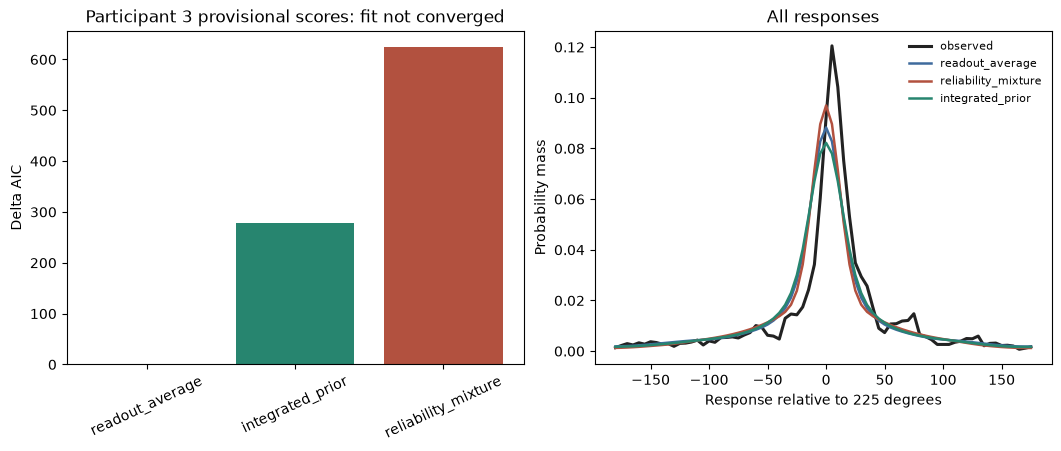

,direction,trials,valid_responses
0,75.0,17,17
1,115.0,34,34
2,125.0,45,45
3,135.0,52,52
4,145.0,52,52


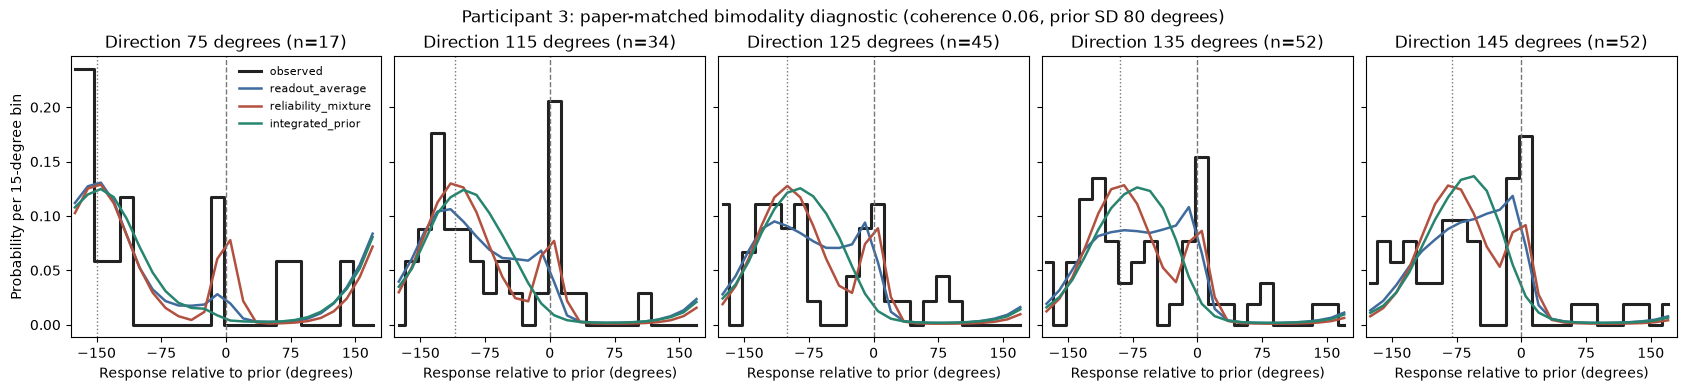

In [8]:
overview_figure = score_and_response_figure(
    subject,
    GRID,
    predictions,
    score_table,
)
overview_figure.savefig(
    OUTPUT_DIR / "response_and_score_comparison.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

PAPER_COHERENCE = 0.06
PAPER_PRIOR_STD = 80.0
PAPER_DIRECTIONS = (75.0, 115.0, 125.0, 135.0, 145.0)
PLOTTING_COLUMNS = [
    "subject_id",
    "session_id",
    "run_id",
    "trial_index",
    "motion_direction",
    "motion_coherence",
    "prior_std",
]
header = pd.read_csv(DATA_CSV, nrows=0)
missing_plot_columns = sorted(set(PLOTTING_COLUMNS).difference(header.columns))
if missing_plot_columns:
    raise ValueError(f"Paper diagnostic requires plotting columns: {missing_plot_columns}")

plotting_rows = pd.read_csv(DATA_CSV, usecols=PLOTTING_COLUMNS)
plotting_rows = (
    plotting_rows.loc[plotting_rows["subject_id"] == subject.subject_id]
    .sort_values(["subject_id", "session_id", "run_id", "trial_index"], kind="mergesort")
    .reset_index(drop=True)
)
if len(plotting_rows) != subject.n_trials:
    raise ValueError("Plotting metadata does not align with the prepared participant trials.")
np.testing.assert_allclose(plotting_rows["motion_direction"], subject.directions)
np.testing.assert_array_equal(plotting_rows["session_id"], subject.session_ids)
np.testing.assert_array_equal(plotting_rows["run_id"], subject.run_ids)
np.testing.assert_array_equal(plotting_rows["trial_index"], subject.trial_indices)

paper_base_selector = (
    np.isclose(plotting_rows["motion_coherence"].to_numpy(dtype=float), PAPER_COHERENCE)
    & np.isclose(plotting_rows["prior_std"].to_numpy(dtype=float), PAPER_PRIOR_STD)
)
paper_selectors = {
    direction: paper_base_selector
    & np.isclose(subject.directions, direction)
    for direction in PAPER_DIRECTIONS
}
diagnostic_counts = pd.DataFrame(
    {
        "direction": PAPER_DIRECTIONS,
        "trials": [int(selector.sum()) for selector in paper_selectors.values()],
        "valid_responses": [
            int(np.count_nonzero(selector & subject.response_valid))
            for selector in paper_selectors.values()
        ],
    }
)
display(diagnostic_counts)
if (diagnostic_counts["valid_responses"] == 0).any():
    raise ValueError("At least one paper-matched direction has no valid responses.")

paper_figure = paper_bimodality_figure(
    subject,
    GRID,
    predictions,
    paper_selectors,
    coherence=PAPER_COHERENCE,
    prior_std=PAPER_PRIOR_STD,
    bin_width_degrees=15.0,
)
paper_figure.savefig(
    OUTPUT_DIR / "paper_matched_bimodality_diagnostic.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## Learned state trajectories

The two kappa-learning models report expected prior concentration. The
reliability-mixture model reports its scalar prior reliance. Gray lines mark
session boundaries, where every model is reset under the shared contract.

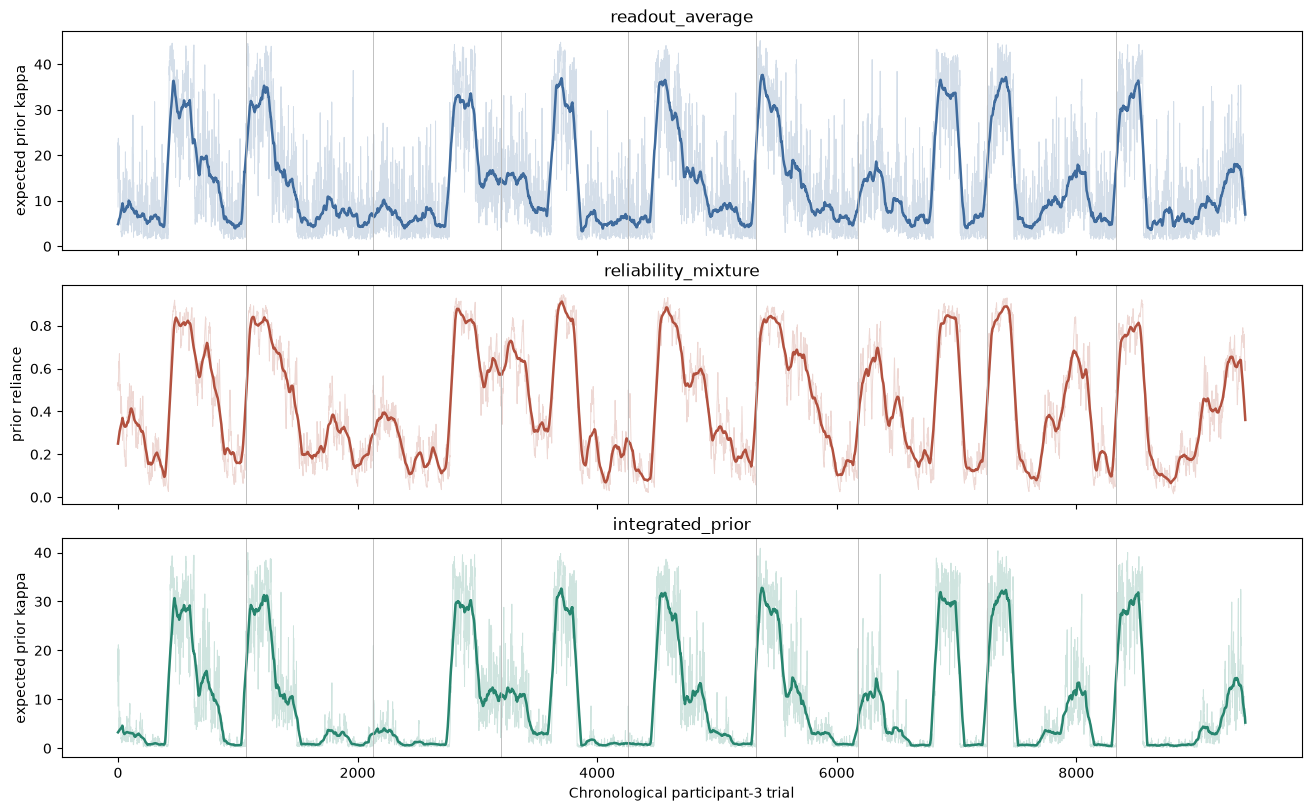

In [9]:
figure = state_figure(subject, predictions, smoothing_window=75)
figure.savefig(OUTPUT_DIR / "learned_state_trajectories.png", dpi=180, bbox_inches="tight")
plt.show()

## Interpretation gate

- Do not interpret AIC/BIC ordering unless `comparison_valid` is true for every
  row and the convergence table has been inspected.
- Parameters reported as unchanged or at a bound require scrutiny even after a
  nominally successful optimizer exit.
- Assess bimodality in the five paper-matched panels, not in a pooled or
  automatically selected 60-degree condition.
- The 80-degree `prior_std` label is descriptive plotting metadata only; all
  model states and updates continue to infer prior confidence from trial
  history without receiving that label.
- A full scientific comparison should add sequence-preserving held-out scoring
  and parameter recovery under this same standardized contract.
- Smoke-mode scores are pipeline checks and must not be reported as final fits.